In [1]:
import numpy as np
A = np.array([ [12, 5, 8, 20], [ 7, 15, 3, 11], [25, 9, 18, 6], [10, 14, 2, 16] ])
m=np.mean(A, axis=1)
print("Mean of each row:", m)

arr=np.where(A>m,1,0)
print("Modified array:\n", arr)

count = np.sum(A > m, axis=1)
max_row_index = np.argmax(count)
print("Row with maximum number of elements greater than the mean:", max_row_index)


Mean of each row: [11.25  9.   14.5  10.5 ]
Modified array:
 [[1 0 0 1]
 [0 1 0 1]
 [1 0 1 0]
 [0 1 0 1]]
Row with maximum number of elements greater than the mean: 0


In [2]:
import numpy as np
X = np.array([ [10, 100, 5], [12, 110, 6], [11, 105, 7], [13, 500, 6], [14, 108, 8], [15, 115, 9] ])
mean=np.mean(X, axis=0)
std=np.std(X, axis=0)
outliers = np.abs(X - mean) > 2 * std
median = np.median(X, axis=0)
result = np.where(outliers, median, X)

print("Column means:", mean)
print("Column standard deviations:", std)
print("Outliers:\n", outliers)
print("Column medians:", median)
print("Modified array:\n", result)


Column means: [ 12.5        173.           6.83333333]
Column standard deviations: [  1.70782513 146.31017281   1.34370962]
Outliers:
 [[False False False]
 [False False False]
 [False False False]
 [False  True False]
 [False False False]
 [False False False]]
Column medians: [ 12.5 109.    6.5]
Modified array:
 [[ 10. 100.   5.]
 [ 12. 110.   6.]
 [ 11. 105.   7.]
 [ 13. 109.   6.]
 [ 14. 108.   8.]
 [ 15. 115.   9.]]


In [3]:
import pandas as pd
df = pd.DataFrame({ 'Student': ['A','B','C','D','E','F','G','H'],  'Department': ['CSE','CSE','ECE','ECE','CSE','ECE','CSE','ECE'],  'Gender': ['F','M','F','M','M','F','F','M'],  'Marks': [85,72,91,65,78,88,95,70], 'Attendance': [92,81,96,72,85,90,98,75] })
avg_marks_dept = df.groupby('Department')['Marks'].mean()
print(avg_marks_dept)
avg_marks_dept_gender = df.groupby(['Department', 'Gender'])['Marks'].mean()
print(avg_marks_dept_gender)

toppers=df.loc[df.groupby('Department')['Marks'].idxmax()]
print(toppers)

dept_mean=df.groupby('Department')['Marks'].transform('mean')
above_avg_students=df[df['Marks']>dept_mean]
print(above_avg_students)

highest_avg_attendance=df.groupby(df['Student'])['Attendance'].mean()
print(highest_avg_attendance)

Department
CSE    82.5
ECE    78.5
Name: Marks, dtype: float64
Department  Gender
CSE         F         90.0
            M         75.0
ECE         F         89.5
            M         67.5
Name: Marks, dtype: float64
  Student Department Gender  Marks  Attendance
6       G        CSE      F     95          98
2       C        ECE      F     91          96
  Student Department Gender  Marks  Attendance
0       A        CSE      F     85          92
2       C        ECE      F     91          96
5       F        ECE      F     88          90
6       G        CSE      F     95          98
Student
A    92.0
B    81.0
C    96.0
D    72.0
E    85.0
F    90.0
G    98.0
H    75.0
Name: Attendance, dtype: float64


In [4]:
df = pd.DataFrame({ 'ID': [101,102,103,101,104,102,105],  'Name': ['A','B','C','A','D','B','E'], 'Age': [20,21,22,20,23,21,24],  'Score': [80,75,90,85,88,75,92] })

duplicate_id=df[df.duplicated('ID', keep=False)]
print("Duplicate ID:\n",duplicate_id)


for uid in duplicate_id:
    sub_df = df[df['ID'] == uid]

    fully_identical = sub_df.duplicated().any()
    meta_identical = sub_df.drop(columns=['Score']).duplicated().any()






Duplicate ID:
     ID Name  Age  Score
0  101    A   20     80
1  102    B   21     75
3  101    A   20     85
5  102    B   21     75


In [5]:
import pandas as pd

df = pd.DataFrame({
    'Date': [ '2026-01-01', '2026-01-02', '2026-01-04', '2026-01-05', '2026-01-08', '2026-01-09' ],
    'Sales': [100, 120, 150, 130, 180, 200]
})

df['Date'] = pd.to_datetime(df['Date'])

full_range = pd.date_range(start=df['Date'].min(), end=df['Date'].max(), freq='D')
missing_dates = full_range.difference(df['Date'])

df_reindexed = df.set_index('Date').reindex(full_range)
df_reindexed.index.name = 'Date'

df_reindexed['Rolling_Avg'] = df_reindexed['Sales'].rolling(window=3, min_periods=1).mean()

max_rolling_date = df_reindexed['Rolling_Avg'].idxmax()

print(df_reindexed)
print(max_rolling_date.strftime('%Y-%m-%d'))


            Sales  Rolling_Avg
Date                          
2026-01-01  100.0        100.0
2026-01-02  120.0        110.0
2026-01-03    NaN        110.0
2026-01-04  150.0        135.0
2026-01-05  130.0        140.0
2026-01-06    NaN        140.0
2026-01-07    NaN        130.0
2026-01-08  180.0        180.0
2026-01-09  200.0        190.0
2026-01-09


In [6]:
import numpy as np

P = np.array([[1, 2], [4, 6], [7, 3], [2, 8], [9, 5]])

diff = P[:, np.newaxis, :] - P[np.newaxis, :, :]
D = np.sqrt(np.sum(diff**2, axis=-1))

max_idx = np.unravel_index(np.argmax(D), D.shape)

print(D)
print(max_idx)


[[0.         5.         6.08276253 6.08276253 8.54400375]
 [5.         0.         4.24264069 2.82842712 5.09901951]
 [6.08276253 4.24264069 0.         7.07106781 2.82842712]
 [6.08276253 2.82842712 7.07106781 0.         7.61577311]
 [8.54400375 5.09901951 2.82842712 7.61577311 0.        ]]
(np.int64(0), np.int64(4))


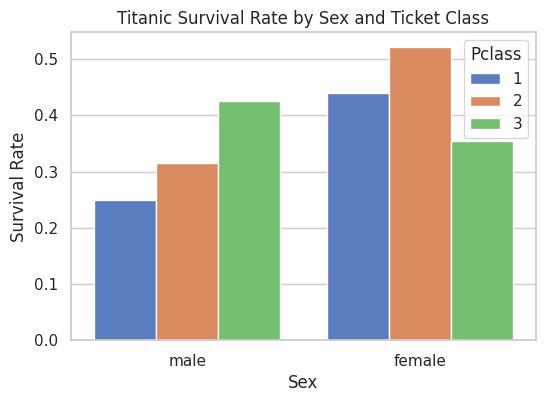

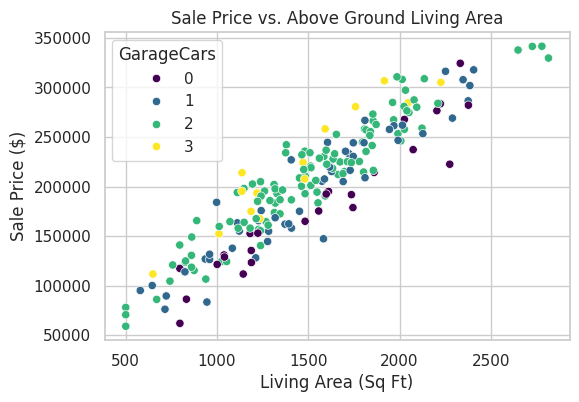

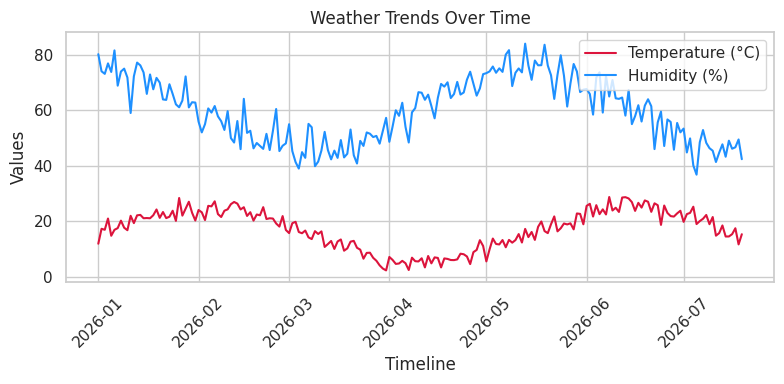

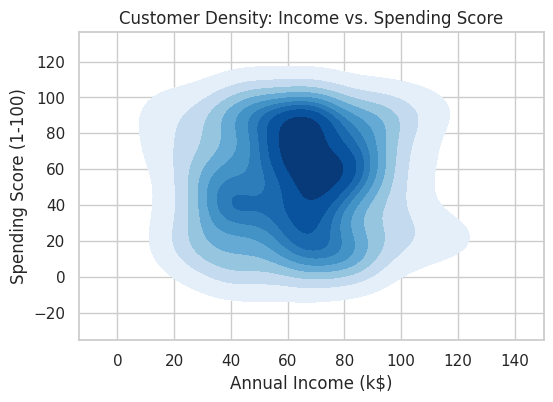

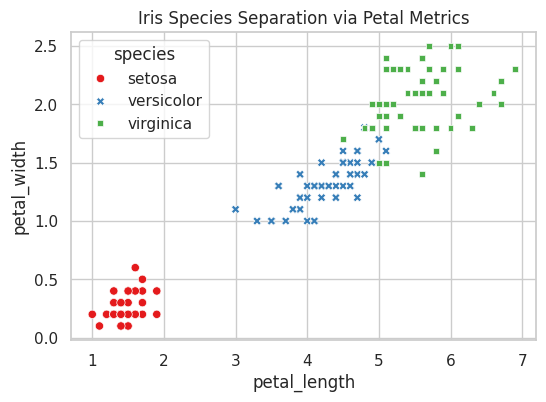

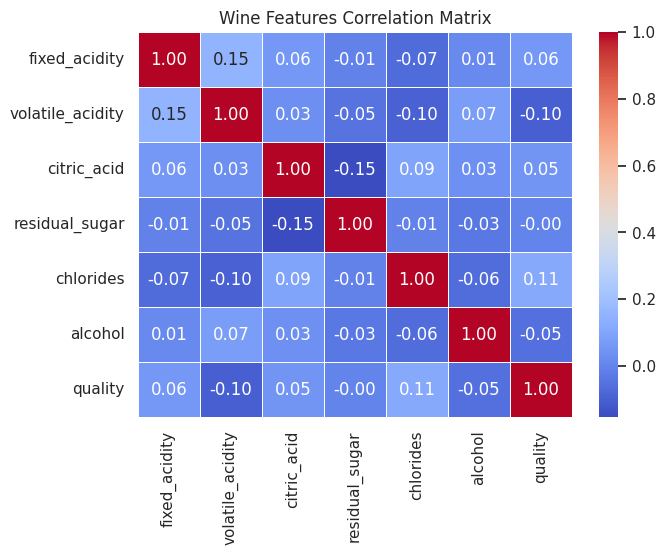

/tmp/ipykernel_2957/2319971390.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_hr, x='Left_Status', y='Satisfaction', palette='pastel')


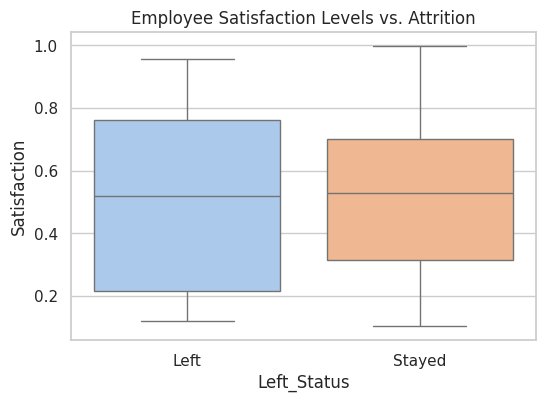

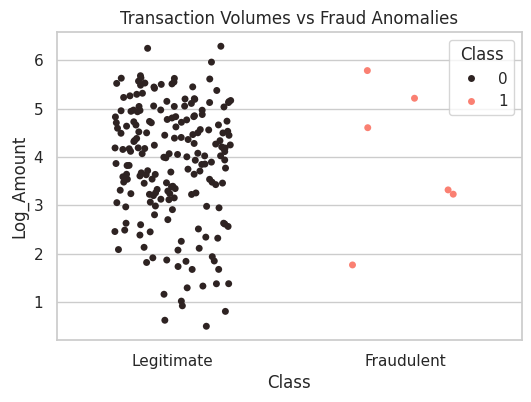

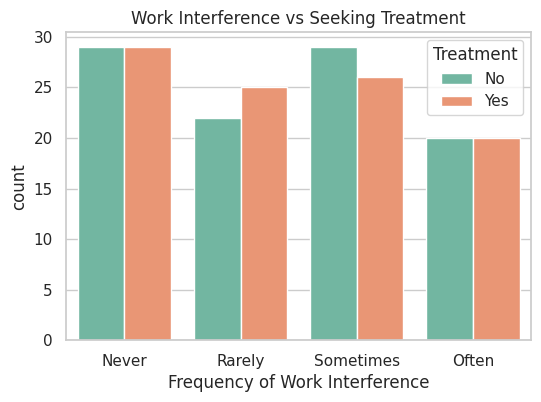

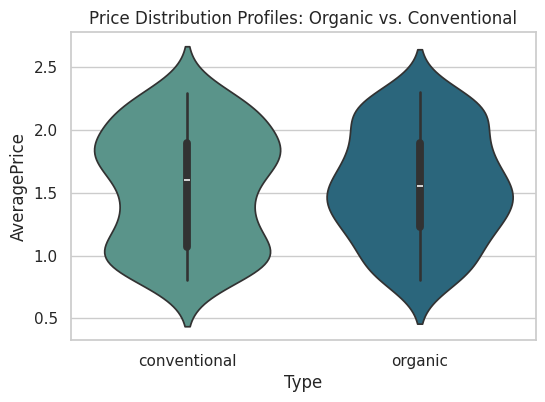

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

sns.set_theme(style="whitegrid")
np.random.seed(42)
n = 200


titanic_data = {
    'PassengerId': range(1, n+1),
    'Survived': np.random.choice([0, 1], size=n, p=[0.6, 0.4]),
    'Pclass': np.random.choice([1, 2, 3], size=n, p=[0.25, 0.25, 0.5]),
    'Sex': np.random.choice(['male', 'female'], size=n),
    'Age': np.random.choice([np.nan, 22, 38, 26, 35, 54, 2, 27, 14, 4], size=n),
    'Fare': np.random.exponential(scale=32, size=n)
}
df_titanic = pd.DataFrame(titanic_data)
df_titanic['Age'] = df_titanic['Age'].fillna(df_titanic['Age'].median())

plt.figure(figsize=(6, 4))
sns.barplot(data=df_titanic, x='Sex', y='Survived', hue='Pclass', errorbar=None, palette='muted')
plt.title('Titanic Survival Rate by Sex and Ticket Class')
plt.ylabel('Survival Rate')
plt.show()


housing_data = {
    'Id': range(1, n+1),
    'GrLivArea': np.random.normal(1500, 500, n).clip(500, 3500),
    'GarageCars': np.random.choice([0, 1, 2, 3], size=n, p=[0.1, 0.3, 0.5, 0.1]),
    'YearBuilt': np.random.randint(1950, 2026, size=n)
}
df_housing = pd.DataFrame(housing_data)
df_housing['SalePrice'] = df_housing['GrLivArea'] * 120 + df_housing['GarageCars'] * 15000 + np.random.normal(0, 20000, n)
df_housing = df_housing[df_housing['SalePrice'] > 0]

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_housing, x='GrLivArea', y='SalePrice', hue='GarageCars', palette='viridis')
plt.title('Sale Price vs. Above Ground Living Area')
plt.xlabel('Living Area (Sq Ft)')
plt.ylabel('Sale Price ($)')
plt.show()


weather_dates = pd.date_range(start="2026-01-01", periods=n, freq="D")
weather_data = {
    'Date': weather_dates,
    'Temperature': 15 + 10 * np.sin(np.linspace(0, 3 * np.pi, n)) + np.random.normal(0, 2, n),
    'Humidity': 60 + 15 * np.cos(np.linspace(0, 3 * np.pi, n)) + np.random.normal(0, 5, n),
    'Rainfall': np.random.exponential(scale=2, size=n)
}
df_weather = pd.DataFrame(weather_data)
df_weather['Rainfall'] = df_weather['Rainfall'].clip(lower=0)

plt.figure(figsize=(8, 4))
sns.lineplot(data=df_weather, x='Date', y='Temperature', label='Temperature (°C)', color='crimson')
sns.lineplot(data=df_weather, x='Date', y='Humidity', label='Humidity (%)', color='dodgerblue')
plt.title('Weather Trends Over Time')
plt.xlabel('Timeline')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


customer_data = {
    'CustomerID': range(1001, 1001+n),
    'Age': np.random.randint(18, 70, size=n),
    'AnnualIncome': np.random.normal(60, 25, size=n).clip(15, 150),
    'SpendingScore': np.random.randint(1, 101, size=n)
}
df_customers = pd.DataFrame(customer_data)
df_customers['SpendingScore'] = df_customers['SpendingScore'].clip(1, 100)

plt.figure(figsize=(6, 4))
sns.kdeplot(data=df_customers, x='AnnualIncome', y='SpendingScore', cmap='Blues', fill=True, thresh=0.05)
plt.title('Customer Density: Income vs. Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()


iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
df_iris['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
df_iris = df_iris.drop_duplicates()

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_iris, x='petal_length', y='petal_width', hue='species', style='species', palette='Set1')
plt.title('Iris Species Separation via Petal Metrics')
plt.show()


wine_data = {
    'fixed_acidity': np.random.uniform(4, 15, n),
    'volatile_acidity': np.random.uniform(0.1, 1.2, n),
    'citric_acid': np.random.uniform(0, 1, n),
    'residual_sugar': np.random.uniform(1, 20, n),
    'chlorides': np.random.uniform(0.01, 0.2, n),
    'alcohol': np.random.uniform(8, 15, n),
    'quality': np.random.randint(3, 9, size=n)
}
df_wine = pd.DataFrame(wine_data)
df_wine.columns = [c.lower().strip() for c in df_wine.columns]

plt.figure(figsize=(7, 5))
corr_matrix = df_wine.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Wine Features Correlation Matrix')
plt.show()


hr_data = {
    'EmpID': range(1, n+1),
    'Satisfaction': np.random.uniform(0.1, 1.0, n),
    'Evaluation': np.random.uniform(0.4, 1.0, n),
    'Projects': np.random.randint(2, 8, size=n),
    'Left': np.random.choice([0, 1], size=n, p=[0.76, 0.24])
}
df_hr = pd.DataFrame(hr_data)
df_hr['Left_Status'] = df_hr['Left'].map({0: 'Stayed', 1: 'Left'})

plt.figure(figsize=(6, 4))
sns.boxplot(data=df_hr, x='Left_Status', y='Satisfaction', palette='pastel')
plt.title('Employee Satisfaction Levels vs. Attrition')
plt.show()


fraud_data = {
    'Time': np.sort(np.random.uniform(0, 86400, n)),
    'Amount': np.random.exponential(scale=90, size=n),
    'Class': np.random.choice([0, 1], size=n, p=[0.95, 0.05])
}
df_fraud = pd.DataFrame(fraud_data)
df_fraud['Log_Amount'] = np.log1p(df_fraud['Amount'])

plt.figure(figsize=(6, 4))
sns.stripplot(data=df_fraud, x='Class', y='Log_Amount', hue='Class', palette='dark:salmon', jitter=0.25)
plt.title('Transaction Volumes vs Fraud Anomalies')
plt.xticks([0, 1], ['Legitimate', 'Fraudulent'])
plt.show()


survey_data = {
    'Country': np.random.choice(['US', 'UK', 'Canada', 'Germany'], size=n),
    'Tech_Company': np.random.choice(['Yes', 'No'], size=n),
    'Treatment': np.random.choice(['Yes', 'No'], size=n),
    'Work_Interfere': np.random.choice(['Often', 'Sometimes', 'Never', 'Rarely'], size=n)
}
df_survey = pd.DataFrame(survey_data)
df_survey['Work_Interfere'] = df_survey['Work_Interfere'].fillna('Unknown')

plt.figure(figsize=(6, 4))
sns.countplot(data=df_survey, x='Work_Interfere', hue='Treatment', palette='Set2', order=['Never', 'Rarely', 'Sometimes', 'Often'])
plt.title('Work Interference vs Seeking Treatment')
plt.xlabel('Frequency of Work Interference')
plt.show()


avocado_data = {
    'Date': pd.date_range(start="2024-01-01", periods=n, freq="W"),
    'AveragePrice': np.random.uniform(0.8, 2.3, n),
    'TotalVolume': np.random.uniform(10000, 500000, n),
    'Type': np.random.choice(['conventional', 'organic'], size=n)
}
df_avocado = pd.DataFrame(avocado_data)
df_avocado['Year'] = df_avocado['Date'].dt.year

plt.figure(figsize=(6, 4))
sns.violinplot(data=df_avocado, x='Type', y='AveragePrice', hue='Type', palette='crest', legend=False)
plt.title('Price Distribution Profiles: Organic vs. Conventional')
plt.show()
